<a href="https://colab.research.google.com/github/Ayushsan1/Pytorch-Implementation-and-Foundation/blob/main/_03_ComputerVision_in_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Computer Vision Using PyTorch
We would be now teaching computer the ability to see images and video frames, like a model built to identify if the image is of Dog or Cat

###Computer Vision PyTorch Workflow

1. Load Image/graphic data
2. prepare data - Pytorch DataLoader
3. Build baseline model - for multiclass classification
4. making prdction and evaluate
5. Device Agnostic Code
6. Modelling - Add Non - Linearity
7. Modelling - Add CNN Layers
8. Camparing Our models
9. Evaluating best models
10. making confusion matrix
11. saving and loading model

In [2]:
#importing all necessary PyTorch Library useful in computer vision
import torchvision
from torchvision.transforms import ToTensor
from PIL import Image
from torchvision import datasets
from torch import nn
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

#### here we are going to start with clothing dataset - particular "FashionMNIST" dataset, this dataset would help us build model which can identify diffrent types of cloth in a single image , similar to the Multi-class classification

In [3]:
#device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
# Downloading and suhSetup training data
train_data = datasets.FashionMNIST(
    root="data", # where to download data to?
    train=True, # get training data
    download=True, # download data if it doesn't exist on disk
    transform=ToTensor(), # images come as PIL format, we want to turn into Torch tensors
    target_transform=None # you can transform labels as well
)

# Downloading and Setup testing data
test_data = datasets.FashionMNIST(
    root="data",
    train=False, # get test data
    download=True,
    transform=ToTensor()
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.74MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.8MB/s]


In [5]:
image, label = train_data[0] #here train_data is FashionMNIST own to call
# image, label  #run this to visualise the image data in values

In [6]:
image.shape

torch.Size([1, 28, 28])

#### Means that it has color_channel =1 and height and width =28 of the image

In [7]:
label

9

In [8]:
# How many samples are there?
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [9]:
train_data.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

Because we're working with 10 different classes, it means our problem is multi-class classification.

###Visualizing the Data , to see how our different clothing pixels represents in data form and classification required to label them correctly

Image shape: torch.Size([1, 28, 28])


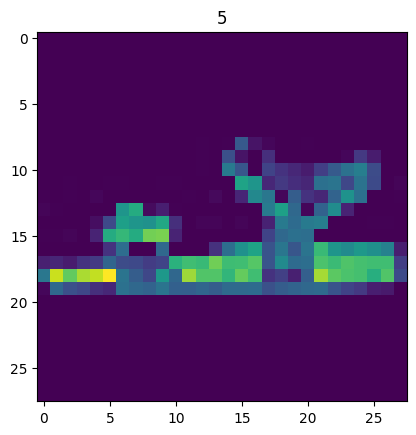

In [10]:
import matplotlib.pyplot as plt
image, label = train_data[59999] #we can chnage index number see different class / clothings data in visualisation only till the 60000 as we have only that much data features
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze()) # image shape is [1, 28, 28] (colour channels, height, width)
plt.title(label);

In [11]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

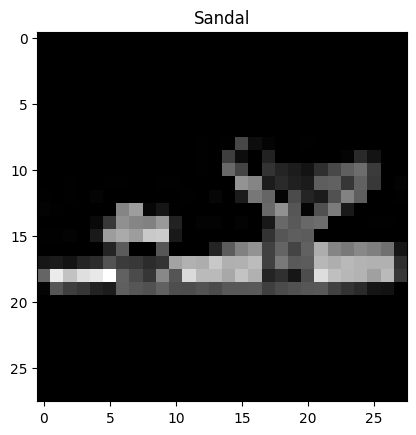

In [12]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label]);

##Preparing DataLoader
Lets now load that image data into the Model, We may do this using ' torch.utils.dataloader' or in short Dataloader only.
We would further use this for Training and inference purpose. **This turns large data in Python iterable smaller chuncks also known as Batches** Setted by Batch_size parameter of the size we want to give.


In [37]:
from numpy.matrixlib import test
from torch.utils.data import DataLoader

#Define a batch size (here 32 fits for kind of most datasets)
BATCH_SIZE=32

#turning data in chunks (batches) - here training data
train_dataloader = DataLoader(train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True) #shuffle data at every epoch - to not let model memorise the data (for generalisation)

test_dataloader = DataLoader(test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False) #don't want to shuffle test data because esting evaluates model performance under consistent, reproducible conditions

print(f"DataLoader: {train_dataloader}, {test_dataloader}\n")
print(f"Length of train dataloader: {len(train_dataloader)}\n") # returns how many batch of 32 ran to cover whole data of 60000
print(f"Length of test dataloader: {len(test_dataloader)}")

DataLoader: <torch.utils.data.dataloader.DataLoader object at 0x7af0867cf8f0>, <torch.utils.data.dataloader.DataLoader object at 0x7af086a000b0>

Length of train dataloader: 1875

Length of test dataloader: 313


### Now as we have have set DataLoader, lets see if it now shows it batch size in it dataloader and how !

In [38]:
# seeing inside the training dataloader
# iter() turns the loader into an iterator,
# and next() grabs the first batch. Unpacking yields feature tensors (train_features_batch) and label tensors (train_labels_batch),
# and checking .shape reveals their dimensions
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape


(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size: torch.Size([1, 28, 28])
Label: 5, label size: torch.Size([])


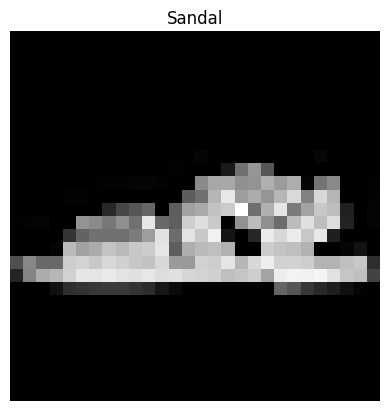

In [39]:
# lets see an sample
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item() #fetches random index from the feature_batch
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="grey")
plt.title(class_names[label])
plt.axis("Off"); #turns off the both axis of x and y
print(f"Image size: {img.shape}")
print(f"Label: {label}, label size: {label.shape}")

##Model_0: Building a Baseline Model

As we have DataLoader prepared and now it is time to build a baseline model, We would keep this as base and keep improving further over it subsequently from simple --> complex model.

We would be using similar pattern as done before, as our base line will consist two 'nn.Linear()' layers but as we working with image data, we are going to use different layer start things off, thats 'nn.Flatten()' layers - this compresses the image tensor (2D, 3D) into 1D (single vector) so that it matches with linear layer

In [40]:
flatten_model = nn.Flatten()

#Get a single sample
x = train_features_batch[0]

#Flatten the sample
output = flatten_model(x)

#print out the result
print(f"Flattened sample:\n{output}")
print(f"Shape before flattening: {x.shape}\nShape after flattening: {output.shape}")

Flattened sample:
tensor([[0.0000, 0.0000, 0.0000, 0.3529, 0.8235, 0.6392, 0.8588, 0.8353, 0.7490,
         0.7098, 0.6902, 0.6902, 0.6902, 0.6745, 0.6471, 0.6510, 0.6471, 0.6431,
         0.6157, 0.6392, 0.5804, 0.7216, 0.6784, 0.6471, 0.5647, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.7686, 0.5059, 0.0000, 0.1569, 0.9882,
         0.8980, 0.8667, 0.8784, 0.8745, 0.8706, 0.9098, 0.9255, 0.9216, 0.8745,
         0.8706, 0.8745, 0.8667, 0.9098, 0.9569, 0.2000, 0.2000, 0.7961, 0.4902,
         0.0000, 0.0039, 0.0000, 0.0000, 0.0000, 0.6706, 0.0039, 0.0000, 0.0000,
         0.6000, 0.8667, 0.8392, 0.8627, 0.8627, 0.8667, 0.8627, 0.8510, 0.8549,
         0.8510, 0.8510, 0.8510, 0.8353, 0.8431, 0.3137, 0.0039, 0.0000, 0.3569,
         0.5529, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.7137, 0.3765, 0.3333,
         0.6784, 0.6549, 0.5804, 0.6902, 0.7333, 0.7529, 0.7843, 0.8078, 0.8314,
         0.8157, 0.8000, 0.7882, 0.7373, 0.6667, 0.7020, 0.6118, 0.4510, 0.0000,
         0

The "nn.Flatten()" took our layer shape from [color_channel, height, width] to [color_channel, height*width]

Now we lets create our first model using 'nn.Flatten()'

In [42]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
      nn.Flatten(),
      nn.Linear(in_features=input_shape, out_features=hidden_units),
      nn.Linear(in_features=hidden_units, out_features=hidden_units),
      nn.Linear(in_features=output_shape, out_features=hidden_units),
      nn.Linear(in_features=len(class_names), out_features=len(class_names))
    )

  def forward(self, x):
    return self.layer_stack(x)

### Now lets give parameters to our model:
1. input_shape = 28*28
2. hidden_units = 10
3. output_shape = len(class_names) --> 10

In [43]:
torch.manual_seed(42)
model_0 = FashionMNISTModelV0(input_shape=784,
                              hidden_units=10,
                              output_shape =len(class_names))#one output each class
model_0.to(device)

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): Linear(in_features=10, out_features=10, bias=True)
  )
)

###Setup Loss, Optimizer and Evaluation Metrics
As we are working on classification problem, we would use helper_function.py and subsequently the accuracy_fn(), which we have used in before in PyTorch Workflow.

In [44]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

helper_functions.py already exists, skipping download


In [45]:
#Import Accuracy Metric
from helper_functions import accuracy_fn # we could also use torchmetrics.Accuracy(task = "multiclass", num_classes = len(class_names)).to(device)

#setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss() # this is also called Cost Function
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

##Creating a Training loop and training the model on batch of data

We'll be using the same steps as the previous notebook(s), though since our data is now in batch form, we'll add another loop to loop through our data batches.

And since we're computing on batches of data, our loss and evaluation metrics will be calculated per batch rather than across the whole dataset.

Let's step through it:

1. Loop through epochs.
2. Loop through training batches, perform training steps, calculate the train loss per batch.
3. Loop through testing batches, perform testing steps, calculate the test loss per batch.
4. Print out what's happening.
5. Time it all (for fun).

In [46]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device: torch.device = None):

  total_time = end - start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time

Let's step through it:

1. Loop through epochs.
2. Loop through training batches, perform training steps, calculate the train   loss per batch.
3. Loop through testing batches, perform testing steps, calculate the test loss per batch.
4. Print out what's happening.
5. Time it all (for fun).

In [47]:
from tqdm.auto import tqdm

# Set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# Set the number of epochs (we'll keep this small for faster training times)
epochs = 3

# Create training and testing loop
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")
    ### Training
    train_loss = 0
    # Add a loop to loop through training batches
    for batch, (X, y) in enumerate(train_dataloader): #enumerate is helpful in generating sequence indexed list
        model_0.train()

        # Move tensors to the target device
        X, y = X.to(device), y.to(device)

        # 1. Optimizer zero grad
        optimizer.zero_grad()

        # 2. Forward pass
        y_pred = model_0(X)

        # 3. Calculate loss (per batch)
        loss = loss_fn(y_pred, y)
        train_loss += loss # accumulatively add up the loss per epoch

        # 4. Loss backward
        loss.backward() #gradients are calculated

        # 5. Optimizer step
        optimizer.step() #here applied gradient with lr and create new weight update

        # Print out how many samples have been seen
        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

    # Divide total train loss by length of train dataloader (average loss per batch per epoch)
    train_loss /= len(train_dataloader)

    ### Testing
    # Setup variables for accumulatively adding up loss and accuracy
    test_loss, test_acc = 0, 0
    model_0.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            # Move tensors to the target device
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred = model_0(X)

            # 2. Calculate loss (accumulatively)
            test_loss += loss_fn(test_pred, y) # accumulatively add up the loss per epoch

            # 3. Calculate accuracy (preds need to be same as y_true)
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

        # Calculations on test metrics need to happen inside torch.inference_mode()
        # Divide total test loss by length of test dataloader (per batch)
        test_loss /= len(test_dataloader) #makes the test loss average number

        # Divide total accuracy by length of test dataloader (per batch)
        test_acc /= len(test_dataloader) #make the test acc average number

    ## Print out what's happening
    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

# Calculate training time
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu,
                                           end=train_time_end_on_cpu,
                                           device=str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.68966 | Test loss: 0.55341, Test acc: 80.55%

Epoch: 1
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.53062 | Test loss: 0.51890, Test acc: 81.76%

Epoch: 2
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.50438 | Test loss: 0.52740, Test acc: 81.74%

Train time on cuda:0: 30.519 seconds


In [48]:
#Model Evaluation for testing loop
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in data_loader:
      #Make Prediction with the model
      X, y = X.to(device), y.to(device) #run X and y on cuda if available
      y_pred = model(X)
      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

    loss /= len(data_loader) #convert loss into the average
    acc /= len(data_loader) #converts accuracy into the average

  return {"model_name": model.__class__.__name__,
          "model_loss": loss.item(),
          "model_acc": acc}

model_0_results = eval_model(model=model_0,
                            data_loader=test_dataloader,
                            loss_fn=loss_fn,
                            accuracy_fn=accuracy_fn)
model_0_results


{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.5274003148078918,
 'model_acc': 81.73921725239616}

##Model_1 : Building a better model with Non-linearity
We will use non-linear function as ReLU() for introducing non-linearity into our model_1

In [49]:
from torch.nn.modules.linear import Linear
class FashionMNISTModelV1(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=len(class_names), out_features=len(class_names))
    )
  def forward( self, x: torch.Tensor):
    return self.layer_stack(x)

giving the same parameter to our new model

In [50]:
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape=784, # number of input features
    hidden_units=10,
    output_shape=len(class_names) # number of output classes desired
).to(device) # send model to GPU if it's available
next(model_1.parameters()).device # check model device

device(type='cuda', index=0)

In [51]:
### Setup Loss function and Optimizer
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

###Start again with Training and testing loop , but now with a function so that we can call it again and again...

* For the training loop we'll create a function called train_step() which takes in a model, a DataLoader a loss function and an optimizer.

* The testing loop will be similar but it'll be called test_step() and it'll take in a model, a DataLoader, a loss function and an evaluation function.

In [52]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
  train_loss, train_acc = 0, 0
  model.to(device)
  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)

    model.train()
    #1. forward pass
    y_pred = model(X)
    #2. calculate loss
    loss = loss_fn(y_pred, y)
    train_loss += loss
    train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
    #3. Optimizer zero grad
    optimizer.zero_grad()
    #4. Backward loss
    loss.backward()
    #5. Optimizer step
    optimizer.step()

  train_loss /= len(dataloader)
  train_acc /= len(dataloader)
  print(f"Train loss: {train_loss: .5f} | Train Accuracy:{train_acc:.2f}")

def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
  test_loss, test_acc = 0, 0
  model.to(device)
  model.eval()

  with torch.inference_mode():
    for X, y in data_loader:
      X, y = X.to(device), y.to(device)
      test_pred = model(X)
      test_loss += loss_fn(test_pred, y)
      test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

    test_loss /= len(data_loader) #averages the loss
    test_acc /= len(data_loader) #average the accuracy
    print(f"Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

In [54]:
torch.manual_seed(42)

from timeit import default_timer as timer
train_time_start_on_gpu = timer()

epochs = 3
for epoch in tqdm(range(epochs)):
  print(f"Epoch : {epoch} \n-------")
  train_step(dataloader=train_dataloader,
             model=model_1,
             loss_fn = loss_fn,
             optimizer= optimizer,
             accuracy_fn = accuracy_fn)
  test_step(data_loader=test_dataloader,
            model=model_1,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn)
train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                            end=train_time_end_on_gpu,
                                            device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch : 0 
-------
Train loss:  0.43240 | Train Accuracy:84.43
Test loss: 0.44860, Test acc: 83.90%

Epoch : 1 
-------
Train loss:  0.42105 | Train Accuracy:84.86
Test loss: 0.47768, Test acc: 83.19%

Epoch : 2 
-------
Train loss:  0.41044 | Train Accuracy:85.10
Test loss: 0.48475, Test acc: 83.23%

Train time on cuda: 31.341 seconds


### No Device error would occur as we have already in all case have set the device agnostic code

In [55]:
torch.manual_seed(42)

model_1_results = eval_model(model=model_1,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn) # we defined this function above only
model_1_results


{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.48475363850593567,
 'model_acc': 83.22683706070288}

In [56]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.5274003148078918,
 'model_acc': 81.73921725239616}

#Convolutional Neural Network

The main 5 building block component of CNN is :
* 1. Tensors - Simply n-dimensional matrix
* 2. Neurons - a function that takes multiple input to yield single output
* 3. Layers - simply the collection of Neurons with same operation including same hyperperameters
* 4. Kernel weights and biases - instead of looking at whole image , CNN places kernel to small region of the image
* 5. Differentiable Score Func/ class Score - it the class (output) score on which CNN decides which class image mostly is of.

**Layers of Typical CNN Structure:**

Input Layer --> [Convolutional layer --> activation layer --> Pooling layer] ---> Output Layer

Activation layer we already know and have implemented in the previous models with nn.Linear(), Now we would need to learn and add two layers as:
1. nn.Con2d()
2. nn.MaxPool2d()

### We have done block wise sequential even when we could have done same inside one sequential block , but this has been done because:

1. Each Block represent a logical stage of Network. Eg: [Feature Extraction --> Deeper Feature Extraction ---> Classification]

2. Shape Tracking becomes easy as we have built block based architecture , we can easily print and see each block shape to see if there is reduction in dimension as expected or not.

3. Closer to Real world archutecture : As like Resnet-50 and VGG represented as block and stage level wise.

In [64]:
#Create a Convolutional Neural Network
class FashionMNISTModelV2(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.block_1 = nn.Sequential(
        nn.Conv2d(in_channels = input_shape,
                  out_channels = hidden_units,
                  kernel_size=(3, 3),
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size=(3, 3),
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2)
    )
    self.block_2 = nn.Sequential(
        nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
        nn.ReLU(),
        nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7, out_features=output_shape)
    )
  def forward(self, x: torch.Tensor):
    x = self.block_1(x)
    x = self.block_2(x)
    x = self.classifier(x)
    return x

torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1,
                              hidden_units=10,
                              output_shape=len(class_names)).to(device)
model_2


FashionMNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [66]:
images =torch.randn(size=(32, 3, 64, 64))
test_image = images[0]

print(f'Image batch shape: {images.shape} --> [batch_size, color_channels, height, width]')
print(f'Single image shape: {test_image.shape} --> [color_channels, height, width]')
print(f'Single image pixel values: \n{test_image}')

Image batch shape: torch.Size([32, 3, 64, 64]) --> [batch_size, color_channels, height, width]
Single image shape: torch.Size([3, 64, 64]) --> [color_channels, height, width]
Single image pixel values: 
tensor([[[-0.0793,  1.6144, -0.4617,  ..., -0.3390,  0.1549, -0.2794],
         [-0.5967,  0.0242,  0.8264,  ...,  0.5394,  0.0590,  0.2875],
         [ 0.0881, -0.0106,  2.0317,  ...,  0.6341, -0.5408,  1.3265],
         ...,
         [ 0.5949,  1.0955,  0.7693,  ..., -0.5738,  0.9187,  0.7561],
         [ 0.4068,  0.9570,  0.2887,  ...,  0.1231,  0.7267,  0.3002],
         [ 1.9694,  0.9515,  1.3571,  ..., -0.7764, -0.4411, -0.2924]],

        [[-0.0115, -0.5974,  2.0710,  ..., -1.6814,  0.9977,  0.6090],
         [-1.2258,  1.6480, -1.4137,  ...,  0.7258,  0.8074, -0.7784],
         [ 1.4650, -0.3883, -0.5527,  ...,  0.5641,  0.2478, -0.1571],
         ...,
         [ 1.5853,  1.6764,  0.3468,  ...,  0.6637, -0.8358,  0.3972],
         [-1.4526,  0.4073,  0.3668,  ...,  0.8799,  0.63

In [81]:
torch.manual_seed(42)

conv_layer = nn.Conv2d(in_channels = 3,
                       out_channels = 10,
                       kernel_size=3,
                       stride=1,
                       padding=0)
conv_layer(test_image)# this would not return mismatch error but as the single image is of [C, H, W] but our
#CNN "nn.Conv2d()" layer expects 4D tensor as input with [N, C, H, W] #[batch_size, Color_channel, height, width]
#so we would add one layer as unsqueeze()
conv_layer(test_image.unsqueeze(dim=0))

tensor([[[[ 0.4308,  1.2368, -0.6056,  ..., -0.5771,  0.5092,  0.6029],
          [ 0.1728,  0.1201,  0.3334,  ...,  0.9820, -0.3648,  0.3929],
          [-0.5700, -0.2093,  1.4068,  ..., -0.4570,  0.6664,  0.4407],
          ...,
          [-0.1123,  0.2007,  0.0256,  ..., -0.2485, -0.2937,  1.2019],
          [ 1.4382,  1.1859, -0.6891,  ...,  0.0615, -0.1020, -0.1389],
          [-0.3151,  0.1077,  0.4338,  ..., -0.0351, -0.2374, -0.3865]],

         [[ 0.0705, -0.4075, -0.6670,  ..., -0.1650, -1.1660, -0.1443],
          [ 0.0360, -0.2798,  0.7168,  ...,  1.1139, -0.1128,  0.8921],
          [-1.5408, -0.4789, -1.0191,  ...,  0.1810,  0.6157, -0.8785],
          ...,
          [-0.2540,  0.6555, -1.2796,  ..., -0.1566, -0.5915, -0.0778],
          [ 0.3122, -1.3105,  0.2163,  ..., -0.3659,  0.6624,  0.3876],
          [ 0.0356, -0.3588, -0.0515,  ..., -0.3323, -0.3442, -1.2892]],

         [[-0.2347,  0.0972,  0.1598,  ..., -0.5194, -0.0770,  0.5179],
          [ 0.4966,  0.4623, -

In [82]:
conv_layer(test_image.unsqueeze(dim=0)).shape

torch.Size([1, 10, 62, 62])

In [84]:
#lets create similar but different another convolutional layer
torch.manual_seed(42)

conv_layer_2 = nn.Conv2d(in_channels=3,
                         out_channels= 10,
                         kernel_size=(5,5),
                         stride=2,
                         padding=0)
conv_layer_2(test_image.unsqueeze(dim=0))

tensor([[[[-0.0286, -0.2417, -0.2417,  ...,  0.2395,  0.3491,  0.1356],
          [ 0.5833,  1.6240,  0.3943,  ...,  0.5334,  0.2898,  0.1578],
          [-0.0413,  0.3512,  0.4739,  ..., -1.0640, -0.0364,  0.2007],
          ...,
          [-0.4149, -0.7127, -0.1395,  ...,  0.7893,  0.2361,  0.0447],
          [-0.7144, -0.1895,  0.4104,  ..., -0.2595,  0.7229, -0.3688],
          [ 0.1663, -0.2374,  0.4961,  ...,  0.6189, -0.2211, -0.5547]],

         [[-0.4531, -0.4560, -0.1729,  ...,  0.2231, -0.7261, -0.5965],
          [ 0.6135, -0.5042, -0.3703,  ...,  0.0067, -1.4989, -0.4941],
          [-0.0112, -0.8736, -0.6043,  ..., -0.6552, -0.0938, -0.0083],
          ...,
          [ 0.3293,  1.2435,  0.4470,  ..., -0.1999,  0.6141,  0.5129],
          [ 0.4198, -0.1364,  1.5367,  ..., -0.1242,  0.5593, -0.4936],
          [ 1.1509,  0.4429,  0.1735,  ..., -0.1579, -0.1995,  0.2458]],

         [[ 1.0226,  0.0611, -0.6162,  ..., -0.5949, -0.1158, -0.1691],
          [ 0.3844, -0.7020,  

In [85]:
conv_layer_2(test_image.unsqueeze(dim=0)).shape

torch.Size([1, 10, 30, 30])

Behind the scene the Conv2d() is compressing the information stored in the image. It does this by performing operations on the input image against its internal perameters.

Step is similarr, Data goes in and the layer try to update their internal parameters (patterns) to lower the loss function with the help of optimizer

In [86]:
print(conv_layer_2.state_dict())

OrderedDict({'weight': tensor([[[[ 0.0883,  0.0958, -0.0271,  0.1061, -0.0253],
          [ 0.0233, -0.0562,  0.0678,  0.1018, -0.0847],
          [ 0.1004,  0.0216,  0.0853,  0.0156,  0.0557],
          [-0.0163,  0.0890,  0.0171, -0.0539,  0.0294],
          [-0.0532, -0.0135, -0.0469,  0.0766, -0.0911]],

         [[-0.0532, -0.0326, -0.0694,  0.0109, -0.1140],
          [ 0.1043, -0.0981,  0.0891,  0.0192, -0.0375],
          [ 0.0714,  0.0180,  0.0933,  0.0126, -0.0364],
          [ 0.0310, -0.0313,  0.0486,  0.1031,  0.0667],
          [-0.0505,  0.0667,  0.0207,  0.0586, -0.0704]],

         [[-0.1143, -0.0446, -0.0886,  0.0947,  0.0333],
          [ 0.0478,  0.0365, -0.0020,  0.0904, -0.0820],
          [ 0.0073, -0.0788,  0.0356, -0.0398,  0.0354],
          [-0.0241,  0.0958, -0.0684, -0.0689, -0.0689],
          [ 0.1039,  0.0385,  0.1111, -0.0953, -0.1145]]],


        [[[-0.0903, -0.0777,  0.0468,  0.0413,  0.0959],
          [-0.0596, -0.0787,  0.0613, -0.0467,  0.0701],


In [88]:
#above we got random numbers for weight and bias tensor
#lets check shape of weight and bias
print(f'conv_layer_2 weight shape: \n{conv_layer_2.weight.shape}\n')
print(f"conv_layer_2 bias shape: \n{conv_layer_2.bias.shape}")

conv_layer_2 weight shape: 
torch.Size([10, 3, 5, 5])

conv_layer_2 bias shape: 
torch.Size([10])


In [92]:
###Lets see what is nn.MaxPool2d() layer in CNN:
print(f'Test Image original shape: {test_image.shape}')
print(f"Test image shape as Unsqueezed dim: {test_image.unsqueeze(dim=0).shape} ")
print(f'Test image shape after Conv2d() layer: {conv_layer_2(test_image.unsqueeze(dim=0)).shape}')

max_pool_layer = nn.MaxPool2d(kernel_size=2, stride=2) #maxpooling application giving kernel size as 2 and stride as 2 for moving kernel

max_pool_layer(conv_layer_2(test_image.unsqueeze(dim=0)))

print(f'Test image shape after Conv2d() and MaxPool2d() the shape is: {max_pool_layer(conv_layer_2(test_image.unsqueeze(dim=0))).shape}')


Test Image original shape: torch.Size([3, 64, 64])
Test image shape as Unsqueezed dim: torch.Size([1, 3, 64, 64]) 
Test image shape after Conv2d() layer: torch.Size([1, 10, 30, 30])
Test image shape after Conv2d() and MaxPool2d() the shape is: torch.Size([1, 10, 15, 15])
